# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example: notebooks/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/data/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths data/hw/hw_3/data/student-name/data.csv
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt


# 1. Print environment details

# 1. Print environment details

current_directory = os.getcwd()
print("Current directory:")
print(current_directory)

print("\nFiles in current directory:")
print(os.listdir())

# 2. Acquire and load dataset

data_path = "week_4/owid-energy-data.csv"

df = pd.read_csv(data_path)

print("\nDataset Preview:")
print(df.head())

Current directory:
/Users/astonchia/Documents/GitHub/datascience-publicpolicy-2026/notebooks

Files in current directory:
['week_2', 'hw', 'week_4', 'week_3', 'Aston_Chia HW3.ipynb']

Dataset Preview:
         country  year iso_code  population  gdp  biofuel_cons_change_pct  \
0  ASEAN (Ember)  2000      NaN         NaN  NaN                      NaN   
1  ASEAN (Ember)  2001      NaN         NaN  NaN                      NaN   
2  ASEAN (Ember)  2002      NaN         NaN  NaN                      NaN   
3  ASEAN (Ember)  2003      NaN         NaN  NaN                      NaN   
4  ASEAN (Ember)  2004      NaN         NaN  NaN                      NaN   

   biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
0                      NaN                      NaN                  NaN   
1                      NaN                      NaN                  NaN   
2                      NaN                      NaN                  NaN   
3                      NaN      

### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
df.info()      # column names, data types, missing values
df.head()      # first 5 rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.2+ MB


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [3]:
# 2. Rename columns and select a clean subset
selected_columns = [
    "country",
    "year",
    "oil_consumption",
    "gas_consumption",
    "coal_consumption",
    "nuclear_consumption",
    "renewables_consumption"
]

energy_df = df[selected_columns].copy()

In [4]:
# 3. Filter row or column filters if necessary
# Filter for Japan and years after 2000

energy_df = energy_df[energy_df["country"] == "Japan"]

energy_df = energy_df[energy_df["year"] >= 2000]

In [5]:
# 4. Handle missing values (NaNs) if necessary


print(energy_df.isnull().sum())

# Remove rows with missing values

energy_df = energy_df.dropna()

print("\nAfter cleaning:")
print(energy_df.isnull().sum())

country                   0
year                      0
oil_consumption           1
gas_consumption           1
coal_consumption          1
nuclear_consumption       1
renewables_consumption    1
dtype: int64

After cleaning:
country                   0
year                      0
oil_consumption           0
gas_consumption           0
coal_consumption          0
nuclear_consumption       0
renewables_consumption    0
dtype: int64


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
# Load GDP dataset

gdp_url = "https://raw.githubusercontent.com/datasets/gdp/master/data/gdp.csv"

gdp_df = pd.read_csv(gdp_url)

# Keep only Japan

gdp_df = gdp_df[gdp_df["Country Name"] == "Japan"]

# Rename columns

gdp_df = gdp_df.rename(columns={
    "Year": "year",
    "Value": "gdp_usd"
})

# Keep only needed columns

gdp_df = gdp_df[
    [
        "year",
        "gdp_usd"
    ]
]

print(gdp_df.head())

      year       gdp_usd
6400  1960  4.741924e+10
6401  1961  5.726676e+10
6402  1962  6.498786e+10
6403  1963  7.437928e+10
6404  1964  8.749059e+10


In [7]:
# 2. Merge your datasets on a common key
merged_df = pd.merge(
    energy_df,
    gdp_df,
    on="year",
    how="inner"
)

print("Merged dataset shape:")
print(merged_df.shape)

print("\nMerged dataset preview:")
print(merged_df.head())

Merged dataset shape:
(24, 8)

Merged dataset preview:
  country  year  oil_consumption  gas_consumption  coal_consumption  \
0   Japan  2000      3179.205322       756.650146       1110.603394   
1   Japan  2001      3076.009521       777.283936       1137.154663   
2   Japan  2002      3026.113037       760.460388       1207.908081   
3   Japan  2003      3117.378662       834.982239       1241.259399   
4   Japan  2004      3048.323975       806.040588       1274.102539   

   nuclear_consumption  renewables_consumption       gdp_usd  
0           886.448792              286.238953  4.968359e+12  
1           885.464172              277.406769  4.374712e+12  
2           860.981812              276.791840  4.182846e+12  
3           626.914612              312.697601  4.519562e+12  
4           774.703491              312.185669  4.893116e+12  


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

The datasets were merged using the year variable as the common key. Both datasets contain annual observations, making year an appropriate matching variable.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Apply groupby aggregation or implement one of the backup grouping strategies
# Split into pre/post 2011 (Fukushima disaster — major energy policy shift)
merged_df["era"] = merged_df["year"].apply(
    lambda y: "Post-Fukushima" if y >= 2011 else "Pre-Fukushima"
)

grouped = merged_df.groupby("era")[
    ["oil_consumption", "gas_consumption", "coal_consumption",
     "nuclear_consumption", "renewables_consumption"]
].agg(["mean", "median", "min", "max"])

print(grouped)

               oil_consumption                                         \
                          mean       median          min          max   
era                                                                     
Post-Fukushima     2221.492018  2243.645020  1877.517578  2665.704590   
Pre-Fukushima      2926.558616  3026.113037  2495.723145  3179.205322   

               gas_consumption                                        \
                          mean       median         min          max   
era                                                                    
Post-Fukushima     1121.143588  1157.081543  916.111694  1247.521240   
Pre-Fukushima       865.203941   834.982239  756.650146   999.367188   

               coal_consumption                                         \
                           mean       median          min          max   
era                                                                      
Post-Fukushima      1358.184467  1369.467407  1260.

- *Extra Credit: Write your economic or policy related interpretation here*

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

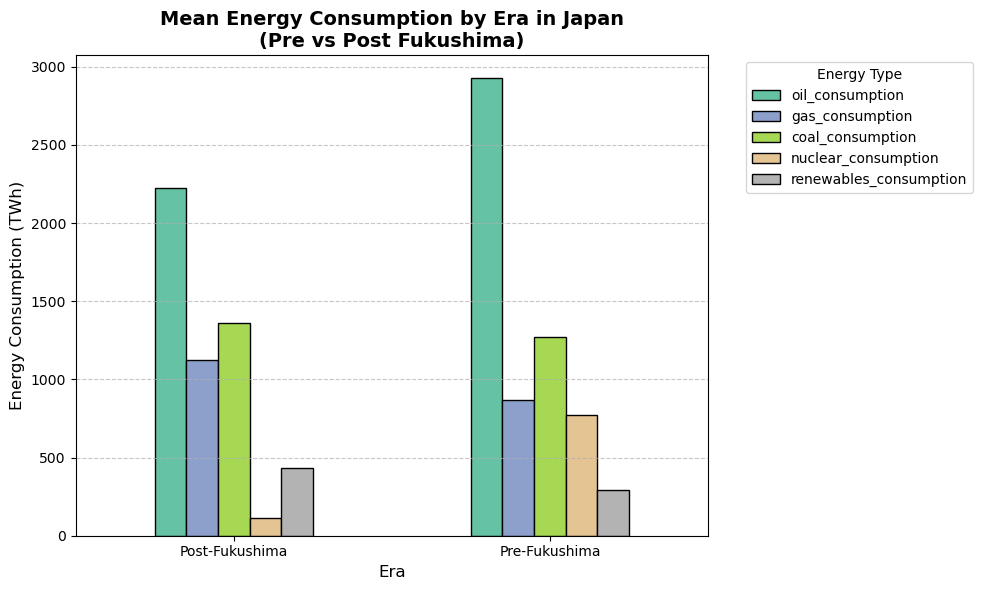

In [9]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
era_means = merged_df.groupby("era")[
    ["oil_consumption", "gas_consumption", "coal_consumption",
     "nuclear_consumption", "renewables_consumption"]
].mean()

era_means.plot(kind="bar", figsize=(10, 6), colormap="Set2", edgecolor="black")

plt.title("Mean Energy Consumption by Era in Japan\n(Pre vs Post Fukushima)", fontsize=14, fontweight="bold")
plt.xlabel("Era", fontsize=12)
plt.ylabel("Energy Consumption (TWh)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Energy Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

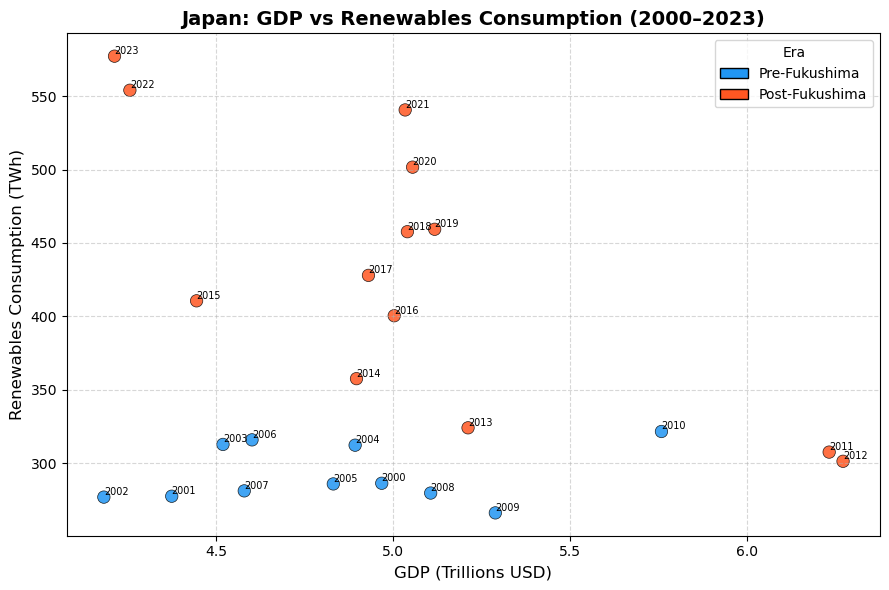

In [10]:
# Plot 2: Customized scatter plot of primary policy variables
fig, ax = plt.subplots(figsize=(9, 6))

colors = merged_df["era"].map({"Pre-Fukushima": "#2196F3", "Post-Fukushima": "#FF5722"})

ax.scatter(
    merged_df["gdp_usd"] / 1e12,
    merged_df["renewables_consumption"],
    c=colors,
    s=80,
    edgecolors="black",
    linewidths=0.5,
    alpha=0.85
)

# Add year labels to each point
for _, row in merged_df.iterrows():
    ax.annotate(str(int(row["year"])), 
                (row["gdp_usd"] / 1e12, row["renewables_consumption"]),
                fontsize=7, ha="left", va="bottom")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", edgecolor="black", label="Pre-Fukushima"),
    Patch(facecolor="#FF5722", edgecolor="black", label="Post-Fukushima")
]
ax.legend(handles=legend_elements, title="Era")

ax.set_title("Japan: GDP vs Renewables Consumption (2000–2023)", fontsize=14, fontweight="bold")
ax.set_xlabel("GDP (Trillions USD)", fontsize=12)
ax.set_ylabel("Renewables Consumption (TWh)", fontsize=12)
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:         log_renewables   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.106
Date:                Fri, 05 Jun 2026   Prob (F-statistic):              0.304
Time:                        15:33:38   Log-Likelihood:                0.16623
No. Observations:                  24   AIC:                             3.668
Df Residuals:                      22   BIC:                             6.024
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.3713      0.473     13.466      0.0

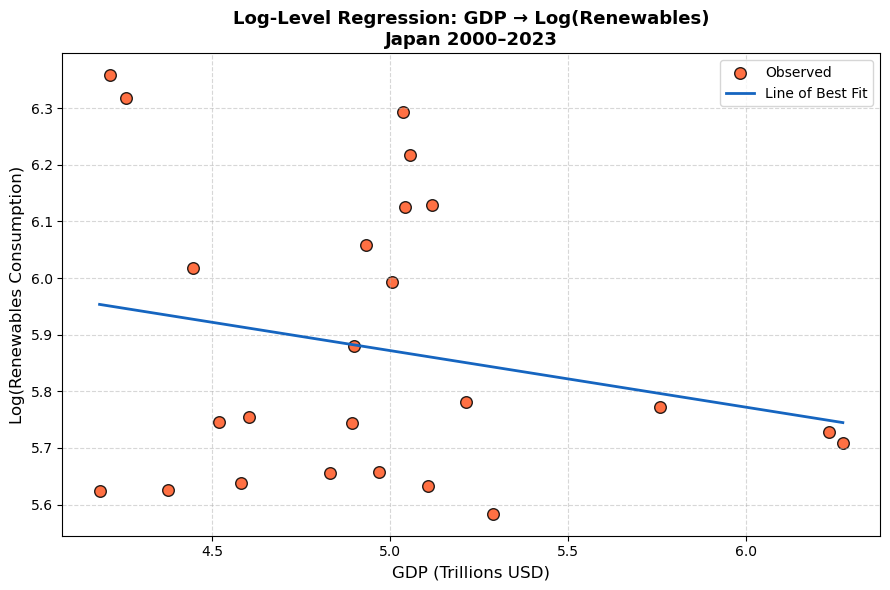


Slope coefficient: -0.0999
Interpretation: A $1 trillion increase in GDP is associated with a -9.99% change in renewables consumption.


In [11]:
# Fit a simple linear regression and overlay the line of best fit
import statsmodels.api as sm
import numpy as np

# Log-Level model: log(renewables) ~ GDP
merged_df["log_renewables"] = np.log(merged_df["renewables_consumption"])

X = sm.add_constant(merged_df["gdp_usd"] / 1e12)
y = merged_df["log_renewables"]

model = sm.OLS(y, X).fit()
print(model.summary())

# Plot scatter + regression line
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    merged_df["gdp_usd"] / 1e12,
    merged_df["log_renewables"],
    color="#FF5722", edgecolors="black", s=70, alpha=0.85, label="Observed"
)

# Regression line
x_range = np.linspace(merged_df["gdp_usd"].min() / 1e12, merged_df["gdp_usd"].max() / 1e12, 100)
y_pred = model.params["const"] + model.params["gdp_usd"] * x_range

ax.plot(x_range, y_pred, color="#1565C0", linewidth=2, label="Line of Best Fit")

ax.set_title("Log-Level Regression: GDP → Log(Renewables)\nJapan 2000–2023", fontsize=13, fontweight="bold")
ax.set_xlabel("GDP (Trillions USD)", fontsize=12)
ax.set_ylabel("Log(Renewables Consumption)", fontsize=12)
ax.legend()
ax.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Interpret the slope
slope = model.params["gdp_usd"]
print(f"\nSlope coefficient: {slope:.4f}")
print(f"Interpretation: A $1 trillion increase in GDP is associated with a "
      f"{slope*100:.2f}% change in renewables consumption.")

Slope coefficient: -0.0999
Interpretation: A $1 trillion increase in GDP is associated with a -9.99% change in renewables consumption.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.